# LOAN APPROVAL PREDICTION

## 1. Introduction

This notebook focuses on building a practical and reliable classification pipeline for predicting loan approval outcomes. Multiple model families are explored and their performance is further refined using Optuna-based hyperparameter optimization and model blending. The dataset used in this study is from the [Kaggle Playground Series S4E10](https://www.kaggle.com/competitions/playground-series-s4e10/overview).

**Problem Statement**

Dream Housing Finance company deals in all home loans. They have presence across all urban, semi urban and rural areas. Customer first apply for home loan after that company validates the customer eligibility for loan.

Company wants to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem to identify the customers segments, those are eligible for loan amount so that they can specifically target these customers.

**Metric**

The evaluation metric for this problem is ROC-AUC..

## 2. Load Data & Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import optuna

train_main = pd.read_csv("train.csv")
test_main = pd.read_csv("test.csv")
train = train_main.copy()
test = test_main.copy()

print("Loaded!")
print("Shape of training dataset: ", train.shape)
print("Shape of testing dataset: ", test.shape)

Loaded!
Shape of training dataset:  (58645, 13)
Shape of testing dataset:  (39098, 12)


In [2]:
train.head(10)

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
5,5,27,45000,RENT,2.0,VENTURE,A,9000,8.94,0.20,N,5,0
6,6,25,45000,MORTGAGE,9.0,EDUCATION,A,12000,6.54,0.27,N,3,0
7,7,21,20000,RENT,0.0,PERSONAL,C,2500,13.49,0.13,Y,3,0
8,8,37,69600,RENT,11.0,EDUCATION,D,5000,14.84,0.07,Y,11,0
9,9,35,110000,MORTGAGE,0.0,DEBTCONSOLIDATION,C,15000,12.98,0.14,Y,6,0


## 3. Exploratory Data Analysis

### 3.1. Data Quality Check

In [3]:
def data_quality_check(df, name):
    missing = df.isna().sum().sum()
    duplicates = df.duplicated().sum()
    
    print(f"{name} → Missing: {missing} | Duplicates: {duplicates}")

data_quality_check(train, "Train")
data_quality_check(test, "Test")

Train → Missing: 0 | Duplicates: 0
Test → Missing: 0 | Duplicates: 0


### 3.2. Target Distribution

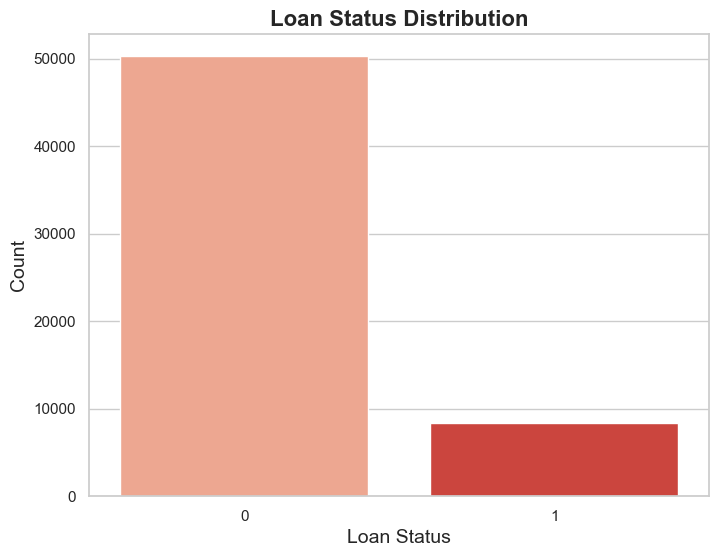

In [4]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='loan_status', data=train, palette='Reds')

ax.set_title('Loan Status Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Loan Status', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

plt.show()

The target variable is imbalanced, making it a central challenge of the problem. Instead of using resampling methods, this notebook focuses on using the right evaluation metric (ROC-AUC), stratified cross-validation and tree-based models (such as LightGBM and XGBoost, which are generally more robust to class imbalance) to handle this issue.

### 3.3. Categorical Feature Insights

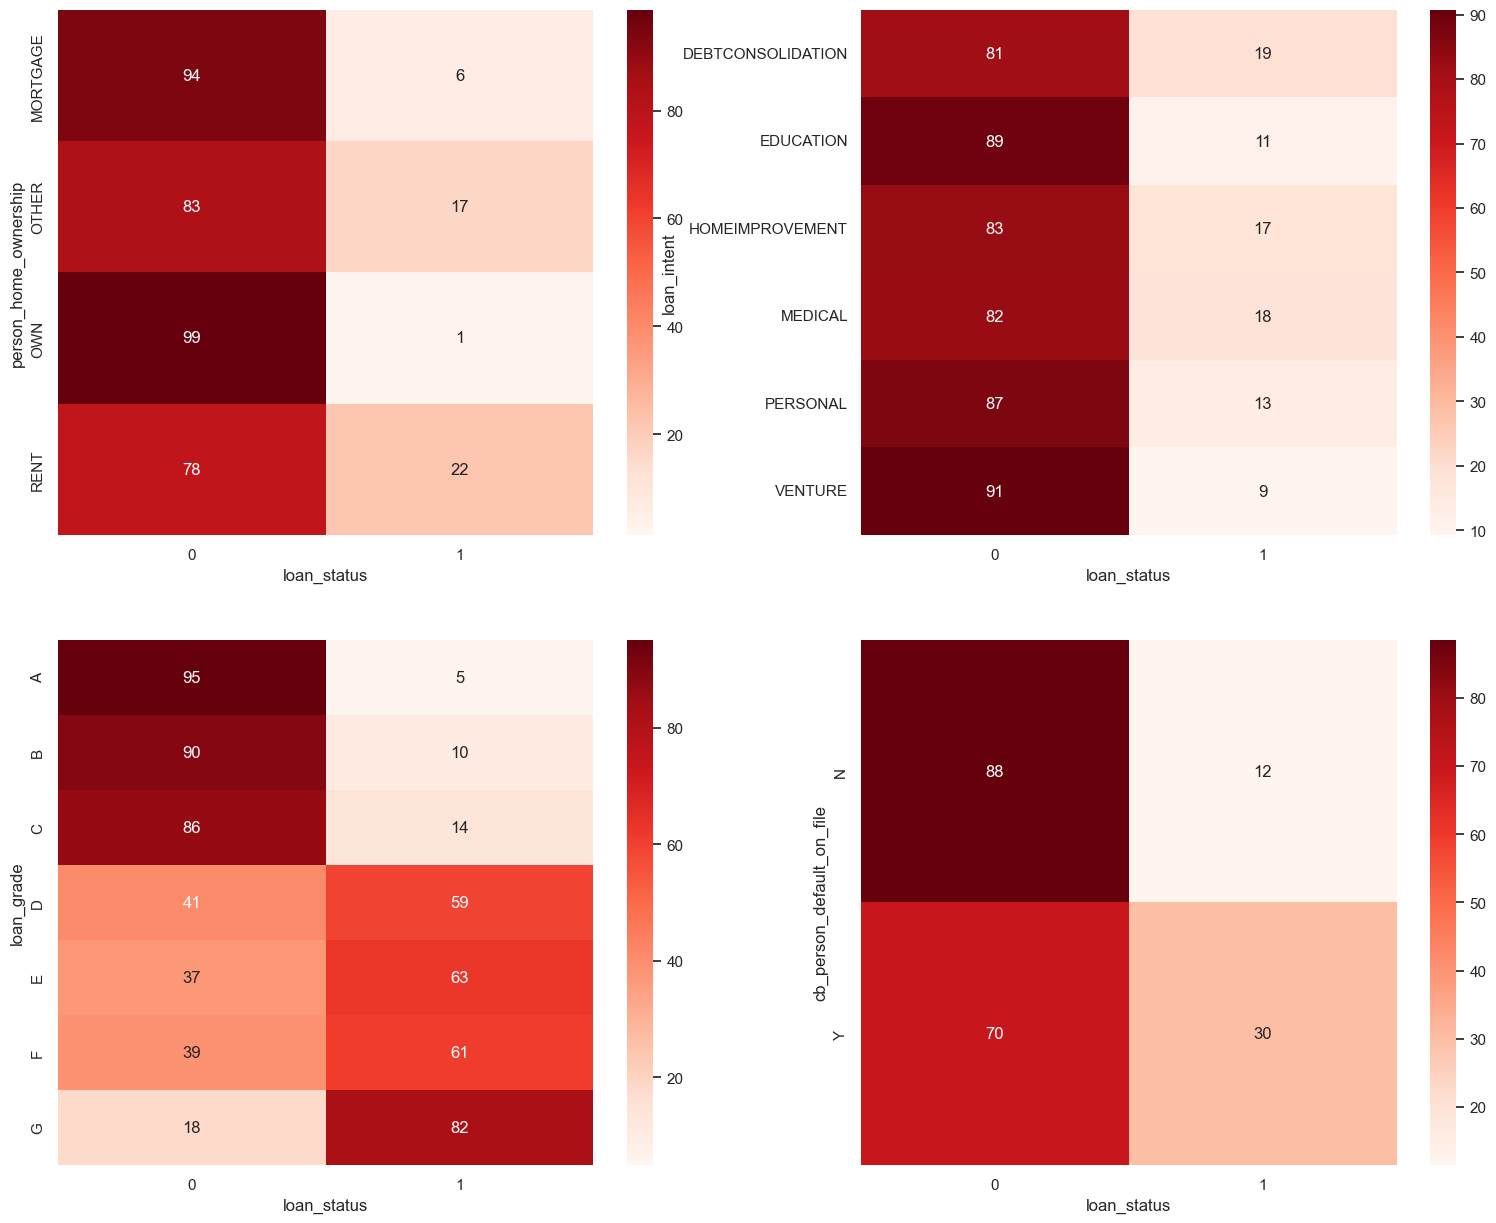

In [5]:
def plot_heatmap(data, feature, ax):
    cmap = sns.color_palette("Reds", as_cmap=True)
    sns.heatmap(data=round(100*pd.crosstab(train[feature], train['loan_status'], normalize=0), 2), 
                annot=True, cmap=cmap, fmt='.0f', ax=ax)

fig, axes = plt.subplots(2, 2, figsize=(19, 15))

plot_heatmap(train, 'person_home_ownership', axes[0, 0])
plot_heatmap(train, 'loan_intent', axes[0, 1])
plot_heatmap(train, 'loan_grade', axes[1, 0])
plot_heatmap(train, 'cb_person_default_on_file', axes[1, 1])

plt.show()

* In the loan_grade vs. loan_status plot, grades D, E, F and G show a significantly higher likelihood of loan_status being 1.
* “Y” in cb_person_default_on_file is associated with a higher likelihood of loan_status being 1.
* For person_home_ownership, “RENT” shows the highest probability of loan_status being 1.
* Overall, loan_grade appears to be the most informative feature so far.

### 3.4. Numerical Feature Behavior & Outliers

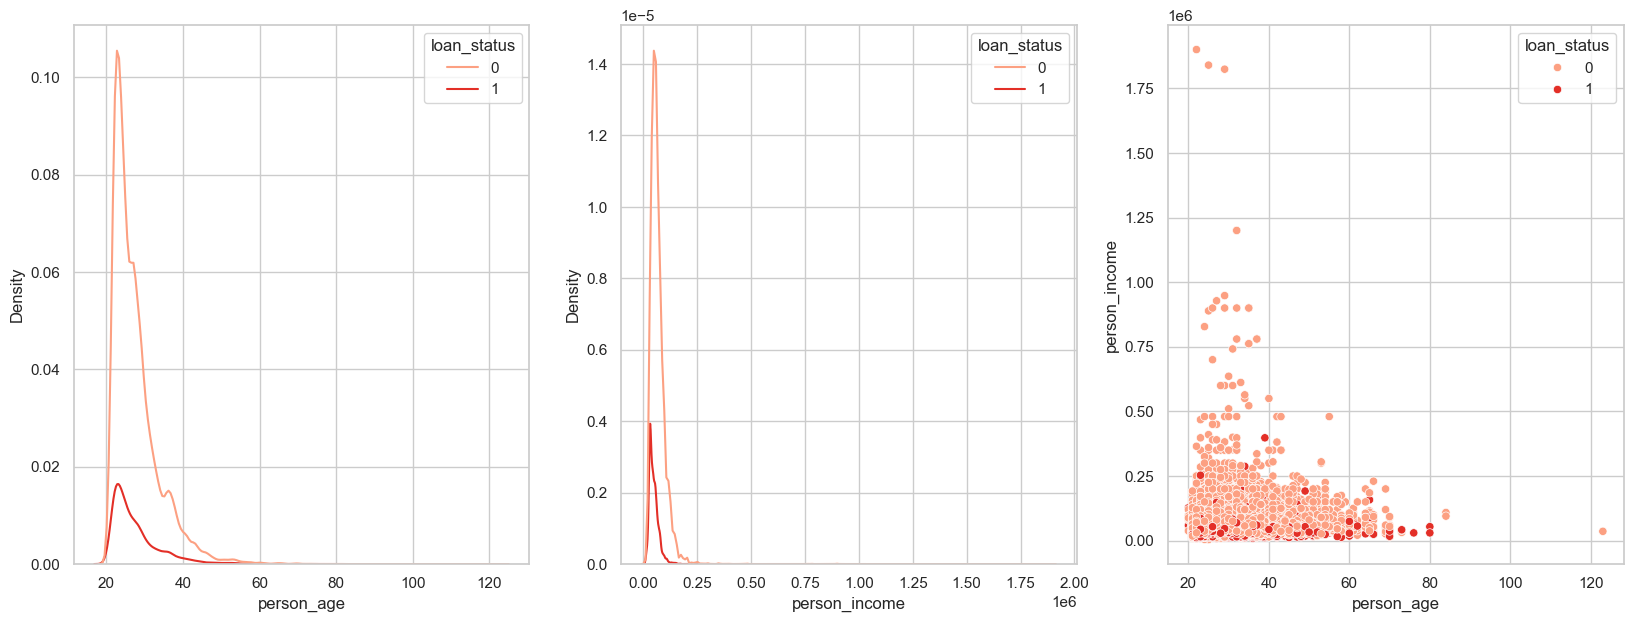

In [6]:
def plot_kde_or_scatter(data, x, y=None, plot_type='kde', ax=None, palette='Reds'):
    if plot_type == 'kde':
        sns.kdeplot(data=data, x=x, hue='loan_status', ax=ax, palette=palette)
    elif plot_type == 'scatter':
        sns.scatterplot(data=data, x=x, y=y, hue='loan_status', ax=ax, palette=palette)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

plot_kde_or_scatter(train, 'person_age', ax=axes[0], palette='Reds')
plot_kde_or_scatter(train, 'person_income', ax=axes[1], palette='Reds')
plot_kde_or_scatter(train, 'person_age', 'person_income', plot_type='scatter', ax=axes[2], palette='Reds')

plt.show()

- An unrealistic age value above 120 was clipped to handle outliers.
- Both features show overlapping distributions, indicating limited predictive power when used individually.
- This limitation is addressed by using tree-based models, which can capture interactions between features and improve predictive performance.

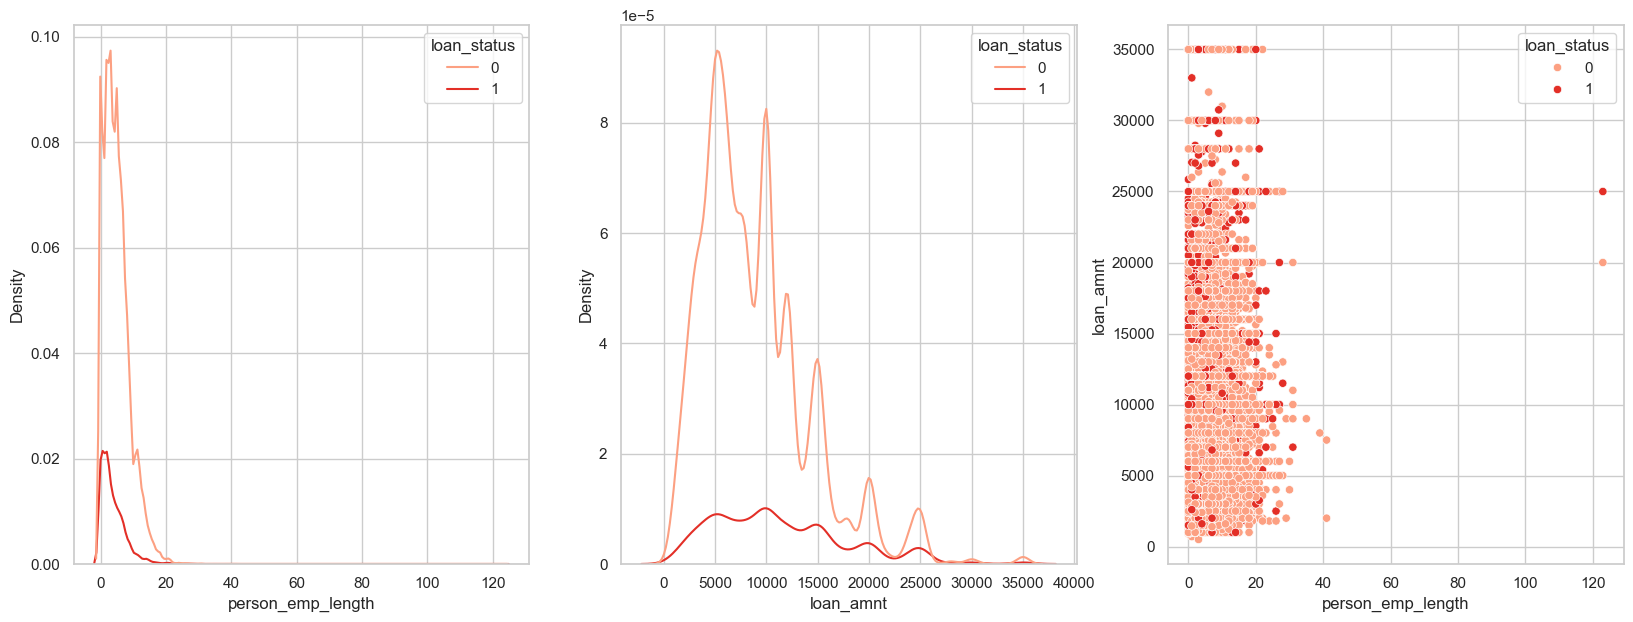

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

plot_kde_or_scatter(train, 'person_emp_length', ax=axes[0], palette='Reds')
plot_kde_or_scatter(train, 'loan_amnt', ax=axes[1], palette='Reds')
plot_kde_or_scatter(train, 'person_emp_length', 'loan_amnt', plot_type='scatter', ax=axes[2], palette='Reds')

plt.show()

* loan_status=0 and loan_status=1 show similar distributions for person_emp_length and loan_amnt, indicating limited separation between classes and weaker individual predictive power.

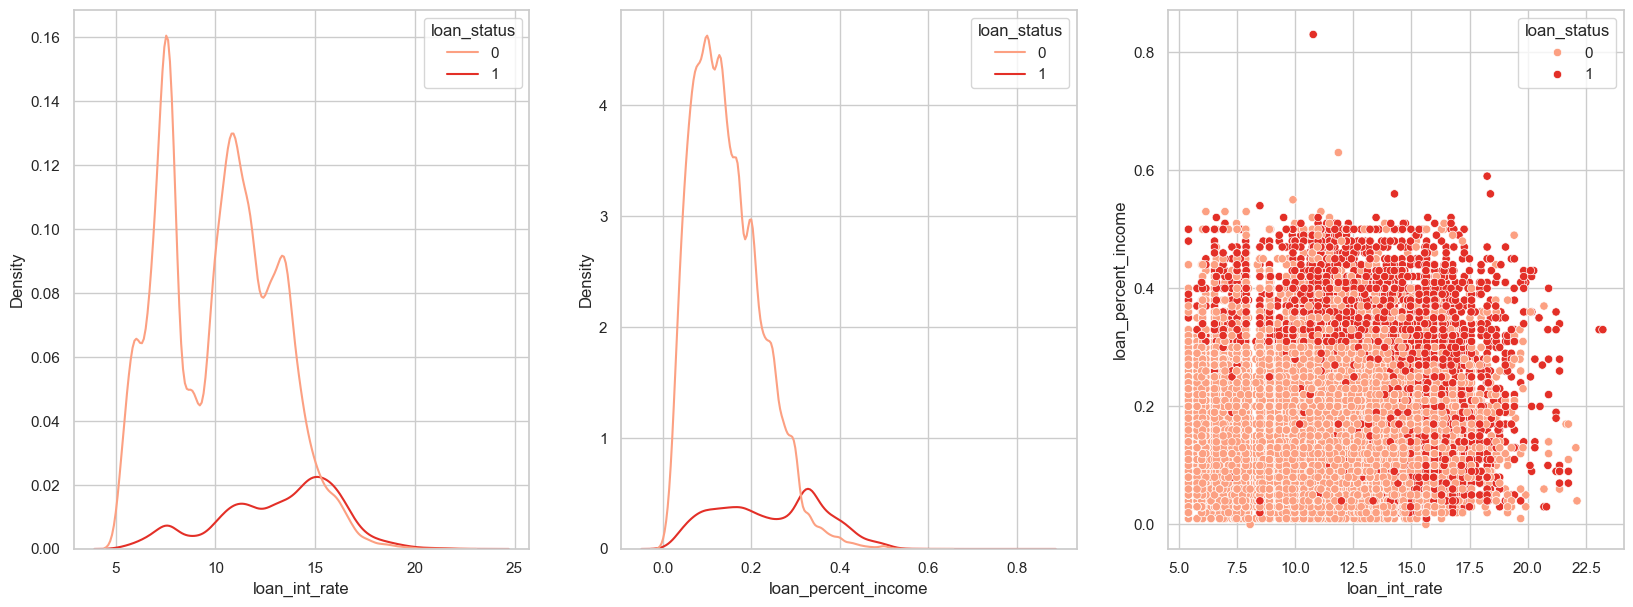

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

plot_kde_or_scatter(train, 'loan_int_rate', ax=axes[0], palette='Reds')
plot_kde_or_scatter(train, 'loan_percent_income', ax=axes[1], palette='Reds')
plot_kde_or_scatter(train, 'loan_int_rate', 'loan_percent_income', plot_type='scatter', ax=axes[2], palette='Reds')

plt.show()

* A few extreme values are observed (interest rates above 22.5 and loan_percent_income above 0.6), but their impact not too much.
* loan_status=0 and loan_status=1 show largely overlapping distributions for both loan_int_rate and loan_percent_income, suggesting that these features alone are not strong predictors.

## 4. Data Processing

* "process_data" function is used to convert data types and handle basic outliers. Categorical features are set to category type and extreme values are clipped to reduce noise.

In [9]:
cat_cols = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"]

def process_data(df, cat_cols, is_train=False):
    df = df.copy()
    df[cat_cols] = df[cat_cols].astype("category")
    df["person_age"] = df["person_age"].clip(upper=90).astype("int32")
    df["person_emp_length"] = df["person_emp_length"].clip(upper=60)
    df["cb_person_cred_hist_length"] = df["cb_person_cred_hist_length"].astype("int32")

    if is_train:
        df["loan_status"] = df["loan_status"].astype("int8")
        
    return df

train = process_data(train, cat_cols, is_train=True)
test = process_data(test, cat_cols)
test_ids = test["id"].copy()

X = train.drop(columns=["id", "loan_status"])
Y = train["loan_status"]
test = test.drop(columns=["id"])

skf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=1,
    random_state=1)

## 5. Modelling

* In this section, multiple tree-based models are trained and evaluated, including Random Forest, LightGBM and XGBoost.
* For each model, hyperparameters are optimized using RandomizedSearchCV, followed by stratified cross-validation to ensure robust performance estimation.
* Out-of-fold (OOF) predictions are collected for all models and final predictions are further improved using an Optuna-based weighted blending approach.

### 5.1. Random Forest Baseline

In [10]:
%%time

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

def prepare_data(df, cat_cols):
    dummies = pd.get_dummies(df[cat_cols], drop_first=True, dtype="int8")
    return pd.concat([df.drop(columns=cat_cols), dummies], axis=1)

RF_train = prepare_data(X, cat_cols)
RF_test = prepare_data(test, cat_cols)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=1
)

random_search.fit(RF_train, Y)

rf_params = random_search.best_params_

print("Best Hyperparameters:", rf_params)

scores = []
rf_oof_preds = []
rf_test_preds = []

for fold, (train_index, valid_index) in enumerate(skf.split(RF_train, Y)):
    X_train_fold = RF_train.iloc[train_index]
    X_valid_fold = RF_train.iloc[valid_index]

    y_train_fold = Y.iloc[train_index]
    y_valid_fold = Y.iloc[valid_index]

    rf_model = RandomForestClassifier(
        **rf_params,
        random_state=42,
        n_jobs=1
    )

    rf_model.fit(X_train_fold, y_train_fold)

    valid_pred = rf_model.predict_proba(X_valid_fold)[:, 1]
    test_pred = rf_model.predict_proba(RF_test)[:, 1]

    rf_oof_preds.append(
        pd.DataFrame({
            "y": y_valid_fold.values,
            "rf_preds": valid_pred,
            "fold": fold
        })
    )

    rf_test_preds.append(
        pd.DataFrame({
            "rf_preds": test_pred,
            "fold": fold
        })
    )

    score = roc_auc_score(y_valid_fold, valid_pred)
    scores.append(score)

    print(f"Fold {fold} ROC-AUC: {score:.6f}")

rf_oof_score = np.mean(scores)
rf_std = np.std(scores)

print(f"Random Forest 10-fold ROC-AUC: {rf_oof_score:.6f}")
print(f"Random Forest ROC-AUC std    : {rf_std:.6f}")

Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}
Fold 0 ROC-AUC: 0.938930
Fold 1 ROC-AUC: 0.946245
Fold 2 ROC-AUC: 0.939793
Fold 3 ROC-AUC: 0.939142
Fold 4 ROC-AUC: 0.939240
Fold 5 ROC-AUC: 0.942064
Fold 6 ROC-AUC: 0.940841
Fold 7 ROC-AUC: 0.937955
Fold 8 ROC-AUC: 0.934448
Fold 9 ROC-AUC: 0.935883
Random Forest 10-fold ROC-AUC: 0.939454
Random Forest ROC-AUC std    : 0.003089
CPU times: user 22min 16s, sys: 18.7 s, total: 22min 35s
Wall time: 22min 38s


### 5.2 LightGBM Classifier

In [11]:
%%time

param_grid = {
    "learning_rate": [0.01, 0.03, 0.1],
    "n_estimators": [100, 150, 200, 300],
    "max_depth": [10, 15, 20, None],
    "reg_alpha": [0.01, 0.1, 0.25],
    "reg_lambda": [0.01, 0.05, 0.1],
    "num_leaves": [31, 38, 50, 100],
    "colsample_bytree": [0.5, 0.7, 0.9]
}

lgb_base = LGBMClassifier(
    verbose=-1,
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X, Y)

lgb_params = random_search.best_params_

print("Best Hyperparameters:", lgb_params)

scores = []
lgb_oof_preds = []
lgb_test_preds = []

for fold, (train_index, valid_index) in enumerate(skf.split(X, Y)):
    X_train_fold = X.iloc[train_index]
    X_valid_fold = X.iloc[valid_index]

    y_train_fold = Y.iloc[train_index]
    y_valid_fold = Y.iloc[valid_index]

    lgb_model = LGBMClassifier(
        **lgb_params,
        verbose=-1,
        random_state=42,
        n_jobs=-1
    )

    lgb_model.fit(X_train_fold, y_train_fold)

    valid_pred = lgb_model.predict_proba(X_valid_fold)[:, 1]
    test_pred = lgb_model.predict_proba(test)[:, 1]

    lgb_oof_preds.append(
        pd.DataFrame({
            "y": y_valid_fold.values,
            "lgb_preds": valid_pred,
            "fold": fold
        })
    )

    lgb_test_preds.append(
        pd.DataFrame({
            "lgb_preds": test_pred,
            "fold": fold
        })
    )

    score = roc_auc_score(y_valid_fold, valid_pred)
    scores.append(score)

    print(f"Fold {fold} ROC-AUC: {score:.6f}")

lgb_oof_score = np.mean(scores)
lgb_std = np.std(scores)

print(f"LightGBM 10-fold ROC-AUC: {lgb_oof_score:.6f}")
print(f"LightGBM ROC-AUC std    : {lgb_std:.6f}")

Best Hyperparameters: {'reg_lambda': 0.05, 'reg_alpha': 0.25, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.5}
Fold 0 ROC-AUC: 0.961255
Fold 1 ROC-AUC: 0.960896
Fold 2 ROC-AUC: 0.962008
Fold 3 ROC-AUC: 0.956339
Fold 4 ROC-AUC: 0.960799
Fold 5 ROC-AUC: 0.962407
Fold 6 ROC-AUC: 0.958573
Fold 7 ROC-AUC: 0.960886
Fold 8 ROC-AUC: 0.955411
Fold 9 ROC-AUC: 0.958630
LightGBM 10-fold ROC-AUC: 0.959720
LightGBM ROC-AUC std    : 0.002263
CPU times: user 23.4 s, sys: 25.2 s, total: 48.6 s
Wall time: 3min 42s


### 5.3. XGBoost Classifier

In [12]:
%%time

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [6, 10, 12, 15],
    "learning_rate": [0.01, 0.03, 0.1, 0.2],
    "gamma": [0, 0.1, 0.2, 0.3],
    "min_child_weight": [1, 5, 10, 20],
    "colsample_bytree": [0.5, 0.7, 0.9]
}

xgb_base = XGBClassifier(
    enable_categorical=True,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X, Y)

xgb_params = random_search.best_params_

print("Best Hyperparameters:", xgb_params)

scores = []
xgb_oof_preds = []
xgb_test_preds = []

for fold, (train_index, valid_index) in enumerate(skf.split(X, Y)):
    X_train_fold = X.iloc[train_index]
    X_valid_fold = X.iloc[valid_index]

    y_train_fold = Y.iloc[train_index]
    y_valid_fold = Y.iloc[valid_index]

    xgb_model = XGBClassifier(
        **xgb_params,
        enable_categorical=True,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train_fold, y_train_fold)

    valid_pred = xgb_model.predict_proba(X_valid_fold)[:, 1]
    test_pred = xgb_model.predict_proba(test)[:, 1]

    xgb_oof_preds.append(
        pd.DataFrame({
            "y": y_valid_fold.values,
            "xgb_preds": valid_pred,
            "fold": fold
        })
    )

    xgb_test_preds.append(
        pd.DataFrame({
            "xgb_preds": test_pred,
            "fold": fold
        })
    )

    score = roc_auc_score(y_valid_fold, valid_pred)
    scores.append(score)

    print(f"Fold {fold} ROC-AUC: {score:.6f}")

xgb_oof_score = np.mean(scores)
xgb_std = np.std(scores)

print(f"XGBoost 10-fold ROC-AUC: {xgb_oof_score:.6f}")
print(f"XGBoost ROC-AUC std    : {xgb_std:.6f}")

Best Hyperparameters: {'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.9}
Fold 0 ROC-AUC: 0.957626
Fold 1 ROC-AUC: 0.959364
Fold 2 ROC-AUC: 0.958418
Fold 3 ROC-AUC: 0.954852
Fold 4 ROC-AUC: 0.956465
Fold 5 ROC-AUC: 0.958622
Fold 6 ROC-AUC: 0.955434
Fold 7 ROC-AUC: 0.957601
Fold 8 ROC-AUC: 0.956364
Fold 9 ROC-AUC: 0.957550
XGBoost 10-fold ROC-AUC: 0.957230
XGBoost ROC-AUC std    : 0.001361
CPU times: user 14.3 s, sys: 6.89 s, total: 21.2 s
Wall time: 1min 12s


### 5.4 Prediction Blending

In [13]:
%%time

oof_preds = pd.concat(
    [
        pd.concat(lgb_oof_preds).reset_index(drop=True),
        pd.concat(xgb_oof_preds)["xgb_preds"].reset_index(drop=True),
        pd.concat(rf_oof_preds)["rf_preds"].reset_index(drop=True)
    ],
    axis=1
)

optuna.logging.set_verbosity(optuna.logging.ERROR)

model_names = ["lgb", "xgb", "rf"]

def objective(trial):
    weights = np.array([
        trial.suggest_float(f"{model}_weight", 0.0, 1.0)
        for model in model_names
    ])

    weights = weights / weights.sum()

    fold_scores = []

    for fold in sorted(oof_preds["fold"].unique()):
        fold_data = oof_preds[oof_preds["fold"] == fold]

        blend_pred = sum(
            weights[i] * fold_data[f"{model}_preds"]
            for i, model in enumerate(model_names)
        )

        fold_score = roc_auc_score(fold_data["y"], blend_pred)
        fold_scores.append(fold_score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=500, n_jobs=-1)

best_weights = study.best_trial.params
weight_sum = sum(best_weights.values())

best_weights = {
    key: value / weight_sum
    for key, value in best_weights.items()
}

print("Best Blend ROC-AUC:", round(study.best_value, 6))
print("Best Weights:")
for key, value in best_weights.items():
    print(f"{key}: {value:.4f}")

blend_scores = []

for fold in sorted(oof_preds["fold"].unique()):
    fold_data = oof_preds[oof_preds["fold"] == fold]

    blend_pred = sum(
        best_weights[f"{model}_weight"] * fold_data[f"{model}_preds"]
        for model in model_names
    )

    blend_scores.append(roc_auc_score(fold_data["y"], blend_pred))

blend_oof_score = np.mean(blend_scores)
blend_std = np.std(blend_scores)

results = pd.DataFrame({
    "Model": ["Random Forest", "LightGBM", "XGBoost", "Optuna Blend"],
    "10-fold OOF ROC-AUC": [
        rf_oof_score,
        lgb_oof_score,
        xgb_oof_score,
        blend_oof_score
    ],
    "ROC-AUC Std": [
        rf_std,
        lgb_std,
        xgb_std,
        blend_std
    ]
})

print(results)

Best Blend ROC-AUC: 0.96026
Best Weights:
lgb_weight: 0.7098
xgb_weight: 0.2900
rf_weight: 0.0002
           Model  10-fold OOF ROC-AUC  ROC-AUC Std
0  Random Forest             0.939454     0.003089
1       LightGBM             0.959720     0.002263
2        XGBoost             0.957230     0.001361
3   Optuna Blend             0.960260     0.001889
CPU times: user 11.9 s, sys: 3.82 s, total: 15.8 s
Wall time: 9.16 s


## 6. Error Analysis

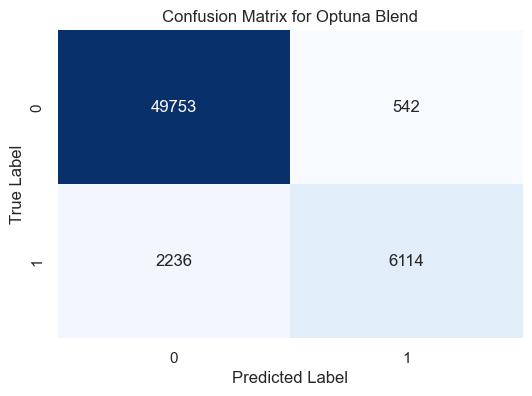

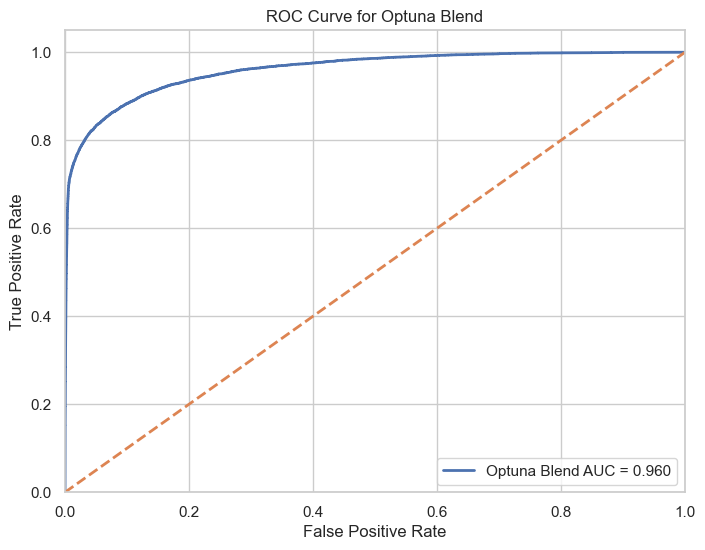

,Model,10-fold OOF ROC-AUC,ROC-AUC Std
0,Random Forest,0.939454,0.003089
1,LightGBM,0.959720,0.002263
2,XGBoost,0.957230,0.001361
3,Optuna Blend,0.960260,0.001889


In [14]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

all_y_true = []
all_blend_preds = []

for fold in sorted(oof_preds["fold"].unique()):
    fold_data = oof_preds[oof_preds["fold"] == fold]

    blend_pred = sum(
        best_weights[f"{model}_weight"] * fold_data[f"{model}_preds"]
        for model in model_names
    )

    all_y_true.extend(fold_data["y"])
    all_blend_preds.extend(blend_pred)

all_y_pred = (np.array(all_blend_preds) > 0.5).astype(int)

cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Optuna Blend")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

fpr, tpr, thresholds = roc_curve(all_y_true, all_blend_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f"Optuna Blend AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Optuna Blend")
plt.legend(loc="lower right")
plt.show()

results

The blended model achieved a strong ROC-AUC score, which means it ranks applicants well by risk probability.

However, the confusion matrix shows an important business issue.  
There are **2,236 false negatives**, meaning these applicants were actually risky (`loan_status = 1`) but predicted as low-risk (`loan_status = 0`).

In a loan approval problem, this is usually the most critical type of error because it may lead to approving risky applicants.

The current classification uses the default threshold of **0.50**.  
This threshold is not necessarily optimal for credit risk decisions.

To improve the decision quality, the next step is to tune the classification threshold.

The goal is to:

- reduce false negatives
- increase risky applicant detection
- compare the trade-off between false negatives and false positives
- select a threshold based on business risk tolerance

## 7. Threshold Tuning

In [15]:
thresholds = np.arange(0.1, 0.9, 0.05)

results_thr = []

for t in thresholds:
    preds = (np.array(all_blend_preds) > t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(all_y_true, preds).ravel()
    
    results_thr.append({
        "threshold": t,
        "false_negative": fn,
        "false_positive": fp,
        "true_positive": tp,
        "true_negative": tn
    })

thr_df = pd.DataFrame(results_thr)
thr_df

,threshold,false_negative,false_positive,true_positive,true_negative
0,0.10,950,5244,7400,45051
1,0.15,1264,3188,7086,47107
2,0.20,1476,2237,6874,48058
3,0.25,1644,1661,6706,48634
4,0.30,1800,1272,6550,49023
5,0.35,1934,987,6416,49308
6,0.40,2061,780,6289,49515
7,0.45,2148,647,6202,49648
8,0.50,2236,542,6114,49753
9,0.55,2312,471,6038,49824


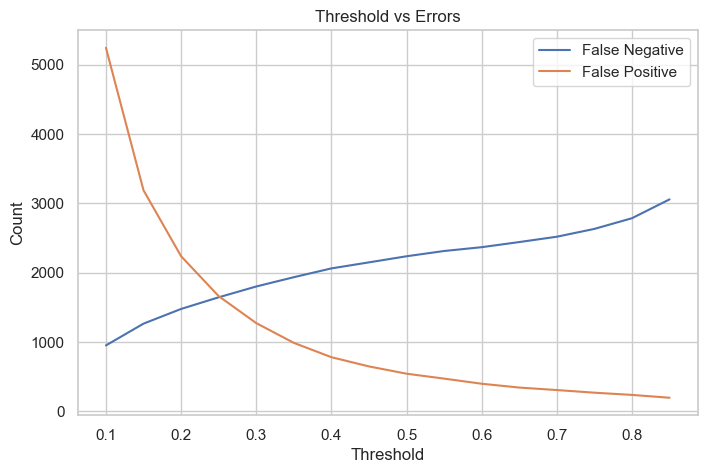

In [16]:
plt.figure(figsize=(8,5))
plt.plot(thr_df["threshold"], thr_df["false_negative"], label="False Negative")
plt.plot(thr_df["threshold"], thr_df["false_positive"], label="False Positive")
plt.xlabel("Threshold")
plt.ylabel("Count")
plt.title("Threshold vs Errors")
plt.legend()
plt.show()

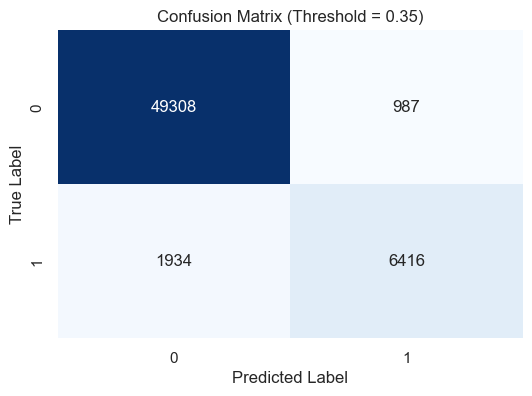

In [17]:
threshold = 0.35

all_y_true = oof_preds["y"].values

all_blend_preds = (
    best_weights["lgb_weight"] * oof_preds["lgb_preds"] +
    best_weights["xgb_weight"] * oof_preds["xgb_preds"] +
    best_weights["rf_weight"] * oof_preds["rf_preds"]
).values

all_y_pred = (all_blend_preds > threshold).astype(int)

cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 8. Conclusion

As expected, there is a clear trade-off between false negatives and false positives as the threshold changes.

At lower thresholds (e.g., 0.10–0.20), the model captures most of the risky applicants, reducing false negatives significantly. However, this leads to a sharp increase in false positives, meaning many safe applicants are rejected.

At higher thresholds (e.g., 0.60 and above), false positives decrease further, but false negatives increase steadily. This results in more risky applicants being incorrectly approved, which is undesirable in a loan approval setting.

At the default threshold of 0.50:
- False Negatives: 2,236  
- False Positives: 542  

This represents a balanced but not risk-sensitive decision boundary.

Based on the analysis, a more suitable range is **0.30–0.40**, where:
- False negatives are significantly reduced (~1800–2060)
- False positives remain at a manageable level (~780–1270)

For this study, a threshold of **0.35** is selected as it provides a better balance between risk detection and customer rejection.

This choice improves the model’s ability to identify risky applicants while keeping false rejections at an acceptable level.

In practice, the final threshold should always be aligned with business priorities and risk tolerance.

## 9. Where This Approach Can Be Applied

The approach used in this notebook is not limited to loan approval problems and can be applied to a wide range of binary classification tasks where decision quality is critical.

Common application areas include:

- **Credit Risk & Lending**  
  Identifying risky applicants and optimizing approval strategies based on risk tolerance.

- **Fraud Detection**  
  Detecting fraudulent transactions while balancing false alarms and missed fraud cases.

- **Insurance Underwriting**  
  Assessing claim risk and adjusting acceptance thresholds accordingly.

- **Customer Churn Prediction**  
  Identifying customers likely to leave and deciding when to intervene.

- **Medical Diagnosis**  
  Supporting decision-making where false negatives and false positives have different consequences.

The key idea is not only to build a high-performing model, but also to align model decisions with business objectives through proper threshold selection and evaluation.